## Metabolomics homework
### Ambrus Csaba

In [1]:
# Init gdrive and python environment

from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/csambrus/MetabolKD.git
%cd /content/MetabolKD
!pip install -r ./requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'MetabolKD' already exists and is not an empty directory.
/content/MetabolKD


In [2]:
import sys
import traceback
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path("/content/MetabolKD")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
from src.runtime_setup import setup_tensorflow_runtime, setup_notebook_error_logger, set_global_seed

set_global_seed()
setup_notebook_error_logger()
setup_tensorflow_runtime()


PROJECT_ROOT: /content/MetabolKD
Globalis seed beallitva: 42
✅ Globális hiba-logger aktív.
TF version: 2.20.0
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU cores:  12
CUDA_VISIBLE_DEVICES = None
TF version = 2.20.0
Built with CUDA = True
GPUs = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs = [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU matmul done in 0.15085268020629883 sec


12

In [ ]:
from src.download_dataset import download_dataset, combine_pos_neg_to_feature_matrix

data = download_dataset()
X, meta = combine_pos_neg_to_feature_matrix(data)

print("NEG raw:", data["neg"].shape)
print("POS raw:", data["pos"].shape)
print("Feature matrix:", X.shape)
print(meta.head())

# Select only baseline samples — sorok szűrése: .loc (X[...] oszlopokat választana)
meta = meta[meta["visit"] == "Baseline"]
X = X.loc[meta.index]


GDRIVE_DATA: megvan /content/drive/MyDrive/MetabolKD/data/ST000816_AN001293_Results.txt
GDRIVE_DATA: megvan /content/drive/MyDrive/MetabolKD/data/ST000816_AN001294_Results.txt
Másolva → /content/MetabolKD/data/ST000816_AN001293_Results.txt
Másolva → /content/MetabolKD/data/ST000816_AN001294_Results.txt
NEG raw: (162, 101)
POS raw: (413, 101)
Feature matrix: (100, 573)
          progressor_status     visit
sample_id                            
S00017985    Non-progressor  Baseline
S00017986    Non-progressor  Followup
S00017987        Progressor  Baseline
S00017988        Progressor  Followup
S00017989    Non-progressor  Baseline


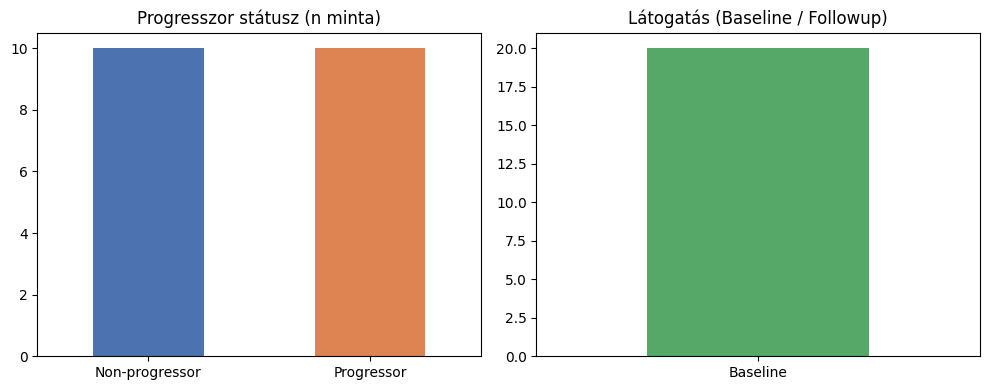

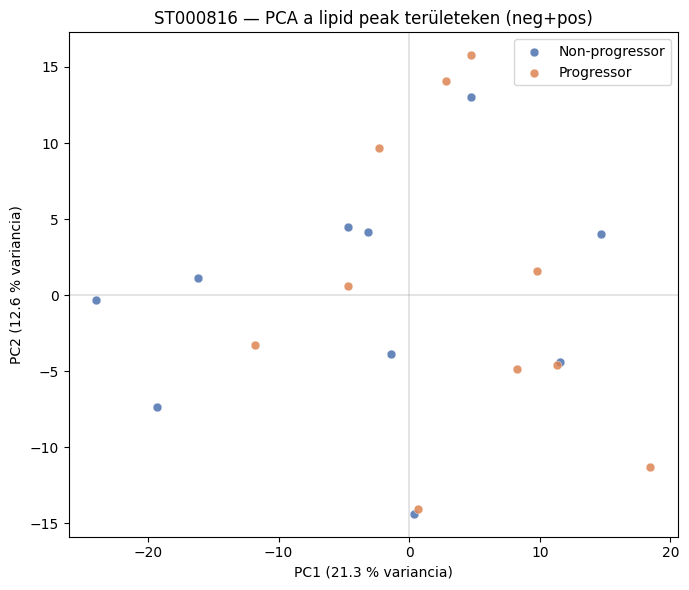

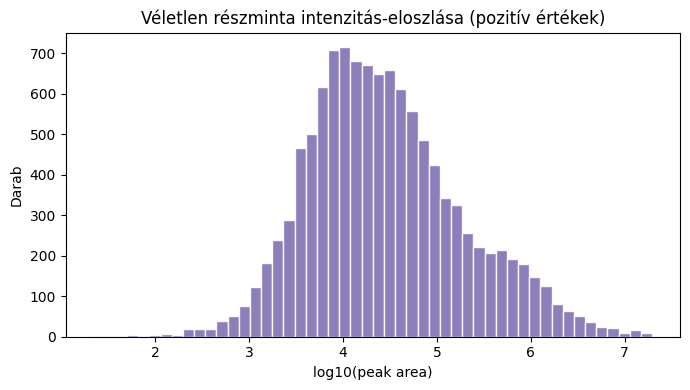

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1) Minta meta: progresszor / visit ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
meta["progressor_status"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Progresszor státusz (n minta)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

meta["visit"].value_counts().plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("Látogatás (Baseline / Followup)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# --- 2) PCA a kombinált feature mátrixon (log1p + skálázás) ---
Xn = np.log1p(X.astype(float).fillna(0).clip(lower=0))
Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
Z = StandardScaler(with_mean=True, with_std=True).fit_transform(Xn)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Z)

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in [("Non-progressor", "#4C72B0"), ("Progressor", "#DD8452")]:
    m = meta["progressor_status"] == label
    ax.scatter(coords[m, 0], coords[m, 1], c=color, s=40, alpha=0.85, label=label, edgecolors="white", linewidths=0.3)
ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f} % variancia)")
ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f} % variancia)")
ax.set_title("ST000816 — PCA a lipid peak területeken (neg+pos)")
ax.legend(loc="best")
ax.axhline(0, color="gray", lw=0.3)
ax.axvline(0, color="gray", lw=0.3)
plt.tight_layout()
plt.show()

# --- 3) Peak intenzitások eloszlása (véletlen 2000 érték, log10) ---
rng = np.random.default_rng(42)
flat = X.to_numpy(dtype=float).ravel()
flat = flat[np.isfinite(flat) & (flat > 0)]
sample_vals = rng.choice(flat, size=min(20_000, flat.size), replace=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(sample_vals), bins=50, color="#8172B3", edgecolor="white", alpha=0.9)
ax.set_xlabel("log10(peak area)")
ax.set_ylabel("Darab")
ax.set_title("Véletlen részminta intenzitás-eloszlása (pozitív értékek)")
plt.tight_layout()
plt.show()